# 06 — Simulación Monte Carlo del Mundial 2026

**Proyecto:** D10Sformer — MIA305 (UdeSA, 2026)  
**Fase:** 6 — Simulación estocástica del torneo completo, 48 equipos, formato FIFA 2026

## Objetivo

1. Entrenar LogReg (mejor baseline calibrado, log_loss=0.86, ECE=0.024) sobre el corpus completo de selecciones (sin val split — ya validamos en Fase 1).
2. Construir features de cada uno de los 48 equipos al inicio del Mundial.
3. Definir un predictor `predict(team_a, team_b) → P(home, draw, away)` que combina ambos features.
4. Correr **10.000 simulaciones** del torneo completo (grupos + 16avos + ... + final).
5. Agregar resultados: para cada equipo, **P(pasa grupo), P(8avos), P(cuartos), P(semis), P(final), P(campeón)**.
6. Visualizar top-10 candidatos al título + barras por etapa.

## Decisiones técnicas justificadas

- **Sampling estocástico, NUNCA argmax.** Cada partido se muestrea de la distribución predicha. Esto produce probabilidades marginales correctas.
- **Features estáticas (no propagamos ELO/form intra-simulación).** Limitación documentada en el paper.
- **Knockout sin empates.** La masa de draw se reparte 50/50 entre home y away (penales).
- **Goles vía Poisson independiente.** Tasa por equipo derivada de P(win) y total esperado de 2.5 goles.

## Pre-requisito

Subir a Drive los archivos nuevos de Fase 6:
- `src/simulation/__init__.py`, `bracket.py`, `simulator.py`
- `tests/test_simulation.py`
- `notebooks/06_montecarlo_wc2026.ipynb`

---
## 1. Setup

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/d10sformer'
except ImportError:
    import os
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/d10sformer


In [4]:
# %load_ext autoreload
# %autoreload 2

In [5]:
import sys, json, pickle
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # Added this import

ROOT = Path(PROJECT_ROOT)
sys.path.insert(0, str(ROOT / 'src'))

DATA_INTERIM = ROOT / 'data' / 'interim'
DATA_PROCESSED = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)

from simulation.bracket import (
    WC2026_GROUPS, WC2026_GROUPS_RAW, GROUP_NAMES, SPANISH_TO_ENGLISH,
    to_english, ALL_KNOCKOUT_MATCHES, assert_bracket_consistency,
)
from simulation.simulator import monte_carlo, simulate_tournament

assert_bracket_consistency()
print(f'✓ Bracket WC 2026 consistente (48 equipos, 12 grupos, 32 partidos KO)')
print(f'  Grupos:')
for grp, teams in WC2026_GROUPS.items():
    print(f'    {grp}: {", ".join(teams)}')


✓ Bracket WC 2026 consistente (48 equipos, 12 grupos, 32 partidos KO)
  Grupos:
    Group_A: Mexico, South Africa, South Korea, Czech Republic
    Group_B: Canada, Bosnia and Herzegovina, Qatar, Switzerland
    Group_C: Brazil, Morocco, Haiti, Scotland
    Group_D: United States, Paraguay, Australia, Turkey
    Group_E: Germany, Curaçao, Ivory Coast, Ecuador
    Group_F: Netherlands, Japan, Tunisia, Sweden
    Group_G: Belgium, Egypt, Iran, New Zealand
    Group_H: Spain, Cape Verde, Saudi Arabia, Uruguay
    Group_I: France, Senegal, Iraq, Norway
    Group_J: Argentina, Algeria, Austria, Jordan
    Group_K: Portugal, Uzbekistan, Colombia, DR Congo
    Group_L: England, Croatia, Ghana, Panama


---
## 2. Cargar el corpus internacional + computar features rolling al inicio del Mundial

Necesitamos para cada equipo el último valor de ELO, form_pts_5 y recent_goals_5. Estos serán los features con los que predecimos cada partido del Mundial.

In [6]:
df_int = pd.read_parquet(DATA_INTERIM / 'international_matches_with_elo.parquet')
df_int['date'] = pd.to_datetime(df_int['date'])
print(f'Partidos internacionales: {len(df_int):,}')
print(f'Rango: {df_int.date.min().date()} → {df_int.date.max().date()}')

Partidos internacionales: 49,257
Rango: 1872-11-30 → 2026-03-31


In [7]:
# Recompute rolling features cronológicamente (igual que Fase 4a)
from collections import defaultdict
import math

df_sorted = df_int.sort_values('date').reset_index(drop=True).copy()
team_history = defaultdict(list)
WINDOW = 5

def rmean(history, idx):
    recent = history[-WINDOW:]
    if not recent: return math.nan
    return sum(x[idx] for x in recent) / len(recent)

home_form, away_form, home_goals, away_goals = [], [], [], []
for _, row in df_sorted.iterrows():
    h, a = row.home_team, row.away_team
    hs, as_ = row.home_score, row.away_score
    home_form.append(rmean(team_history[h], 0))
    away_form.append(rmean(team_history[a], 0))
    home_goals.append(rmean(team_history[h], 1))
    away_goals.append(rmean(team_history[a], 1))
    if pd.notna(hs) and pd.notna(as_):
        if hs > as_:   h_pts, a_pts = 3, 0
        elif hs < as_: h_pts, a_pts = 0, 3
        else:          h_pts, a_pts = 1, 1
        team_history[h].append((h_pts, float(hs)))
        team_history[a].append((a_pts, float(as_)))

df_sorted['home_form_pts_5']     = home_form
df_sorted['away_form_pts_5']     = away_form
df_sorted['home_recent_goals_5'] = home_goals
df_sorted['away_recent_goals_5'] = away_goals

print(f'✓ Features rolling computadas. Cobertura: ~{100*df_sorted.home_form_pts_5.notna().mean():.1f}%')

✓ Features rolling computadas. Cobertura: ~99.7%


In [8]:
# Para cada equipo del Mundial, obtener su ÚLTIMO state (ELO, form, goles)
WC_TEAMS = sorted({t for grp in WC2026_GROUPS.values() for t in grp})
print(f'Equipos del Mundial 2026: {len(WC_TEAMS)}')

# Última fila donde cada equipo jugó como home o away
def latest_state(team):
    rows = df_sorted[(df_sorted.home_team == team) | (df_sorted.away_team == team)]
    if len(rows) == 0:
        return None
    r = rows.iloc[-1]
    if r.home_team == team:
        return {
            'team': team,
            'elo': float(r.home_elo_after) if pd.notna(r.home_elo_after) else float(r.home_elo_before),
            'form_pts': r.home_form_pts_5,
            'recent_goals': r.home_recent_goals_5,
            'last_date': r.date,
        }
    else:
        return {
            'team': team,
            'elo': float(r.away_elo_after) if pd.notna(r.away_elo_after) else float(r.away_elo_before),
            'form_pts': r.away_form_pts_5,
            'recent_goals': r.away_recent_goals_5,
            'last_date': r.date,
        }

team_features = {}
missing = []
for t in WC_TEAMS:
    st = latest_state(t)
    if st is None:
        missing.append(t)
    else:
        team_features[t] = st

print(f'Encontrados: {len(team_features)} / {len(WC_TEAMS)}')
if missing:
    print(f'⚠ Equipos sin datos: {missing}')

# Para equipos sin features (raros, ej. Curaçao puede ser problema de naming), usar default
DEFAULT_FEATURES = {'elo': 1500.0, 'form_pts': 1.0, 'recent_goals': 1.0}
for t in missing:
    team_features[t] = {'team': t, **DEFAULT_FEATURES, 'last_date': None}
    print(f'  → {t}: usando features default')

# Tabla de ELO inicial
tf_df = pd.DataFrame(team_features.values()).sort_values('elo', ascending=False)
print(f'\n--- Top 10 por ELO al inicio del Mundial ---')
print(tf_df.head(10)[['team', 'elo', 'form_pts', 'recent_goals']].to_string(index=False))

Equipos del Mundial 2026: 48
Encontrados: 48 / 48

--- Top 10 por ELO al inicio del Mundial ---
       team         elo  form_pts  recent_goals
      Spain 2209.042791       2.6           3.0
  Argentina 2176.628545       2.4           2.2
     France 2127.760111       2.6           2.8
    England 2070.438407       2.6           2.6
     Brazil 2050.097651       1.4           2.2
   Colombia 2044.715336       2.0           2.0
Netherlands 2016.464941       2.6           3.0
   Portugal 2014.701472       1.6           2.4
    Ecuador 2009.578990       1.4           1.0
    Germany 1988.185891       3.0           3.4


---
## 3. Entrenar LogReg sobre el corpus completo

Usamos el feature matrix de Fase 1 (`src/data/feature_engineering.py`) sobre todo el data desde 2014, sin val/test split. Ya validamos en Fase 1 que LogReg = mejor baseline.

In [9]:
from data.feature_engineering import build_feature_matrix, get_feature_columns, prepare_xy
from models.baselines import LogisticRegressionBaseline

df_full = build_feature_matrix(
    df_sorted, windows_form=(5, 10), h2h_window=5, min_date='2014-01-01',
)
X_full, y_full = prepare_xy(df_full) # Assuming prepare_xy extracts X and y

print(f'Feature matrix: X={X_full.shape}, y={y_full.shape}')
print(f'Columnas: {get_feature_columns(df_full)}')


Feature matrix: X=(11700, 40), y=(11700,)
Columnas: ['tournament_class', 'neutral', 'home_elo', 'away_elo', 'elo_diff', 'expected_home_win_prob', 'home_rest_days', 'away_rest_days', 'home_form5_pts', 'home_form5_gf', 'home_form5_ga', 'home_form5_gd', 'home_form5_n', 'away_form5_pts', 'away_form5_gf', 'away_form5_ga', 'away_form5_gd', 'away_form5_n', 'home_form10_pts', 'home_form10_gf', 'home_form10_ga', 'home_form10_gd', 'home_form10_n', 'away_form10_pts', 'away_form10_gf', 'away_form10_ga', 'away_form10_gd', 'away_form10_n', 'h2h_n_matches', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'h2h_avg_gd_for_home']


In [10]:
# Entrenar LogReg sobre TODO
logreg = LogisticRegressionBaseline()
logreg.fit(X_full, y_full)
print('✓ LogReg entrenado')
fi = logreg.feature_importance()
print('\nFeature importance:')
for name, imp in sorted(fi.items(), key=lambda x: -abs(x[1])):
    print(f'  {name:<30}  {imp:+.4f}')

✓ LogReg entrenado

Feature importance:
  elo_diff                        +0.4785
  away_elo                        +0.2609
  home_elo                        +0.2101
  expected_home_win_prob          +0.1247
  away_form10_pts                 +0.0982
  h2h_avg_gd_for_home             +0.0733
  home_form5_ga                   +0.0623
  away_form5_ga                   +0.0593
  neutral_True                    +0.0584
  neutral_False                   +0.0584
  home_form5_pts                  +0.0532
  away_form5_n                    +0.0530
  home_form5_n                    +0.0513
  home_form10_n                   +0.0507
  away_form10_gf                  +0.0394
  home_form10_gf                  +0.0383
  away_form5_pts                  +0.0373
  away_form5_gd                   +0.0357
  home_form10_ga                  +0.0343
  home_form10_pts                 +0.0298
  h2h_draws                       +0.0295
  away_form10_n                   +0.0293
  away_form10_gd                  +0

---
## 4. Construir el predictor `predict_match(team_a, team_b)`

Toma las features de ambos equipos y devuelve [P(home), P(draw), P(away)].

In [11]:
FEATURE_COLS = get_feature_columns(df_full)
print(f'Columnas que espera LogReg ({len(FEATURE_COLS)}):')
for c in FEATURE_COLS:
    print(f'  - {c}')

Columnas que espera LogReg (33):
  - tournament_class
  - neutral
  - home_elo
  - away_elo
  - elo_diff
  - expected_home_win_prob
  - home_rest_days
  - away_rest_days
  - home_form5_pts
  - home_form5_gf
  - home_form5_ga
  - home_form5_gd
  - home_form5_n
  - away_form5_pts
  - away_form5_gf
  - away_form5_ga
  - away_form5_gd
  - away_form5_n
  - home_form10_pts
  - home_form10_gf
  - home_form10_ga
  - home_form10_gd
  - home_form10_n
  - away_form10_pts
  - away_form10_gf
  - away_form10_ga
  - away_form10_gd
  - away_form10_n
  - h2h_n_matches
  - h2h_home_wins
  - h2h_draws
  - h2h_away_wins
  - h2h_avg_gd_for_home


In [12]:
# The logreg model expects one-hot encoded features. The `fi` variable (feature importance)
# contains the actual names of these features. We must construct our input DataFrame with these.
# This variable should be defined outside the function if it's constant, or determined within.
# For simplicity, I'll define it within the function for this fix.
# It corresponds to logreg.feature_names_
# (using fi.keys() as a proxy from kernel state)
MODEL_EXPECTED_FEATURE_COLS = list(fi.keys())

def build_feature_vector(team_a, team_b, venue='neutral'):
    """Construye un vector con las features esperadas por LogReg, usando team_features."""
    fa = team_features.get(team_a, DEFAULT_FEATURES | {'team': team_a})
    fb = team_features.get(team_b, DEFAULT_FEATURES | {'team': team_b})

    # Initialize all columns to 0.0. This handles all one-hot encoded categories
    # and other numerical features that might not be explicitly set below.
    row_data = {col: 0.0 for col in MODEL_EXPECTED_FEATURE_COLS}

    # --- Fill numerical features ---
    if 'home_elo' in row_data: row_data['home_elo'] = fa['elo']
    if 'away_elo' in row_data: row_data['away_elo'] = fb['elo']
    if 'elo_diff' in row_data: row_data['elo_diff'] = fa['elo'] - fb['elo']

    elo_diff_val = fa['elo'] - fb['elo']
    if 'expected_home_win_prob' in row_data:
        row_data['expected_home_win_prob'] = 1 / (1 + 10**(-elo_diff_val / 400))

    if 'home_rest_days' in row_data: row_data['home_rest_days'] = 0 # Default
    if 'away_rest_days' in row_data: row_data['away_rest_days'] = 0 # Default

    # --- Fill form features (5-match window) ---
    if 'home_form5_pts' in row_data: row_data['home_form5_pts'] = fa['form_pts'] if pd.notna(fa['form_pts']) else DEFAULT_FEATURES['form_pts']
    if 'home_form5_gf' in row_data: row_data['home_form5_gf'] = fa['recent_goals'] if pd.notna(fa['recent_goals']) else DEFAULT_FEATURES['recent_goals']
    if 'home_form5_ga' in row_data: row_data['home_form5_ga'] = 1.0 # Placeholder
    if 'home_form5_gd' in row_data:
        gf = fa['recent_goals'] if pd.notna(fa['recent_goals']) else DEFAULT_FEATURES['recent_goals']
        row_data['home_form5_gd'] = gf - 1.0
    if 'home_form5_n' in row_data: row_data['home_form5_n'] = 5.0

    if 'away_form5_pts' in row_data: row_data['away_form5_pts'] = fb['form_pts'] if pd.notna(fb['form_pts']) else DEFAULT_FEATURES['form_pts']
    if 'away_form5_gf' in row_data: row_data['away_form5_gf'] = fb['recent_goals'] if pd.notna(fb['recent_goals']) else DEFAULT_FEATURES['recent_goals']
    if 'away_form5_ga' in row_data: row_data['away_form5_ga'] = 1.0 # Placeholder
    if 'away_form5_gd' in row_data:
        gf = fb['recent_goals'] if pd.notna(fb['recent_goals']) else DEFAULT_FEATURES['recent_goals']
        row_data['away_form5_gd'] = gf - 1.0
    if 'away_form5_n' in row_data: row_data['away_form5_n'] = 5.0

    # --- Fill form features (10-match window) ---
    if 'home_form10_pts' in row_data: row_data['home_form10_pts'] = fa['form_pts'] if pd.notna(fa['form_pts']) else DEFAULT_FEATURES['form_pts']
    if 'home_form10_gf' in row_data: row_data['home_form10_gf'] = fa['recent_goals'] if pd.notna(fa['recent_goals']) else DEFAULT_FEATURES['recent_goals']
    if 'home_form10_ga' in row_data: row_data['home_form10_ga'] = 1.0
    if 'home_form10_gd' in row_data:
        gf = fa['recent_goals'] if pd.notna(fa['recent_goals']) else DEFAULT_FEATURES['recent_goals']
        row_data['home_form10_gd'] = gf - 1.0
    if 'home_form10_n' in row_data: row_data['home_form10_n'] = 10.0

    if 'away_form10_pts' in row_data: row_data['away_form10_pts'] = fb['form_pts'] if pd.notna(fb['form_pts']) else DEFAULT_FEATURES['form_pts']
    if 'away_form10_gf' in row_data: row_data['away_form10_gf'] = fb['recent_goals'] if pd.notna(fb['recent_goals']) else DEFAULT_FEATURES['recent_goals']
    if 'away_form10_ga' in row_data: row_data['away_form10_ga'] = 1.0
    if 'away_form10_gd' in row_data:
        gf = fb['recent_goals'] if pd.notna(fb['recent_goals']) else DEFAULT_FEATURES['recent_goals']
        row_data['away_form10_gd'] = gf - 1.0
    if 'away_form10_n' in row_data: row_data['away_form10_n'] = 10.0

    # --- Fill H2H features ---
    if 'h2h_n_matches' in row_data: row_data['h2h_n_matches'] = 0.0
    if 'h2h_home_wins' in row_data: row_data['h2h_home_wins'] = 0.0
    if 'h2h_draws' in row_data: row_data['h2h_draws'] = 0.0
    if 'h2h_away_wins' in row_data: row_data['h2h_away_wins'] = 0.0
    if 'h2h_avg_gd_for_home' in row_data: row_data['h2h_avg_gd_for_home'] = 0.0

    # --- Set one-hot encoded categorical features ---
    # For tournament_class, for World Cup simulation, we activate 'tournament_class_world_cup_final'
    if 'tournament_class_world_cup_final' in row_data:
        row_data['tournament_class_world_cup_final'] = 1.0
    # All other 'tournament_class_...' will remain 0.0 from initialization.

    # For neutral venue
    if venue == 'neutral':
        if 'neutral_True' in row_data: row_data['neutral_True'] = 1.0
    else: # Not neutral means home_team has home advantage, so 'neutral_False' is active
        if 'neutral_False' in row_data: row_data['neutral_False'] = 1.0
    # Other neutral_X will remain 0.0 from initialization.

    return pd.DataFrame([row_data], columns=MODEL_EXPECTED_FEATURE_COLS)

# Sanity: test con un partido conocido
x_test = build_feature_vector('Argentina', 'France', venue='neutral')
p_test = logreg.predict_proba(x_test)[0]
print(f'\nArgentina vs France (sanity):')
print(f'  P(home_win) = {p_test[0]:.4f}')
print(f'  P(draw)     = {p_test[1]:.4f}')
print(f'  P(away_win) = {p_test[2]:.4f}')
print(f'  → Sum: {p_test.sum():.4f}')


Argentina vs France (sanity):
  P(home_win) = 0.4415
  P(draw)     = 0.1967
  P(away_win) = 0.3618
  → Sum: 1.0000


In [13]:
def logreg_predictor(team_a, team_b, venue='neutral'):
    """Wrapper que cumple la firma Predictor del simulator."""
    x = build_feature_vector(team_a, team_b, venue=venue)
    probs = logreg.predict_proba(x)[0]
    return probs   # array [p_home, p_draw, p_away]

# Test con varios partidos del WC
test_matches = [
    ('Argentina', 'France'),
    ('Brazil', 'Morocco'),
    ('Mexico', 'South Africa'),
    ('England', 'Croatia'),
    ('Spain', 'Uruguay'),
]
print('=== Predicciones de partidos hipotéticos ===')
print(f'{"home":<15} {"away":<15} {"P(home)":<10} {"P(draw)":<10} {"P(away)":<10}')
for a, b in test_matches:
    p = logreg_predictor(a, b)
    print(f'{a:<15} {b:<15} {p[0]:<10.4f} {p[1]:<10.4f} {p[2]:<10.4f}')

=== Predicciones de partidos hipotéticos ===
home            away            P(home)    P(draw)    P(away)   
Argentina       France          0.4415     0.1967     0.3618    
Brazil          Morocco         0.5594     0.1953     0.2453    
Mexico          South Africa    0.6719     0.1842     0.1439    
England         Croatia         0.5359     0.1889     0.2752    
Spain           Uruguay         0.6535     0.1706     0.1759    


---
## 5. Monte Carlo: 10.000 simulaciones del Mundial

In [14]:
import time
t0 = time.time()
agg = monte_carlo(logreg_predictor, n_iters=10_000, seed=42, progress=True)
elapsed = time.time() - t0
print(f'\n✓ {agg.n_iters:,} simulaciones en {elapsed:.1f}s')
print(f'  ({agg.n_iters / elapsed:.1f} sim/s)')

Monte Carlo (n=10000): 100%|██████████| 10000/10000 [48:41<00:00,  3.42it/s]


✓ 10,000 simulaciones en 2922.0s
  (3.4 sim/s)


In [15]:
df_pred = agg.to_dataframe()
df_pred['Equipo'] = df_pred['team']
df_pred = df_pred[['Equipo', 'P_group_advance', 'P_round_of_16', 'P_quarters', 'P_semis', 'P_final', 'P_champion']]
print('=== Top 16 por probabilidad de campeón ===')
print(df_pred.head(16).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

df_pred.to_csv(REPORTS / 'wc2026_predictions.csv', index=False)
print(f'\n✓ Guardado: {REPORTS / "wc2026_predictions.csv"}')

=== Top 16 por probabilidad de campeón ===
     Equipo  P_group_advance  P_round_of_16  P_quarters  P_semis  P_final  P_champion
      Spain           0.9930         0.7470      0.5711   0.4419   0.3008      0.2136
  Argentina           0.9824         0.6521      0.4917   0.3314   0.2060      0.1380
     France           0.9613         0.7014      0.4754   0.3173   0.1974      0.0986
     Brazil           0.9682         0.6716      0.4401   0.2833   0.1820      0.0864
   Portugal           0.9114         0.5864      0.3410   0.1985   0.1063      0.0588
    England           0.9591         0.6049      0.3676   0.2130   0.1146      0.0535
   Colombia           0.9343         0.5947      0.3395   0.1863   0.0916      0.0472
    Ecuador           0.9691         0.6229      0.3314   0.1818   0.0948      0.0409
Netherlands           0.9046         0.4909      0.2915   0.1522   0.0769      0.0311
Switzerland           0.9768         0.6051      0.2920   0.1395   0.0629      0.0269
     Norway

---
## 6. Visualización: top-15 candidatos al título

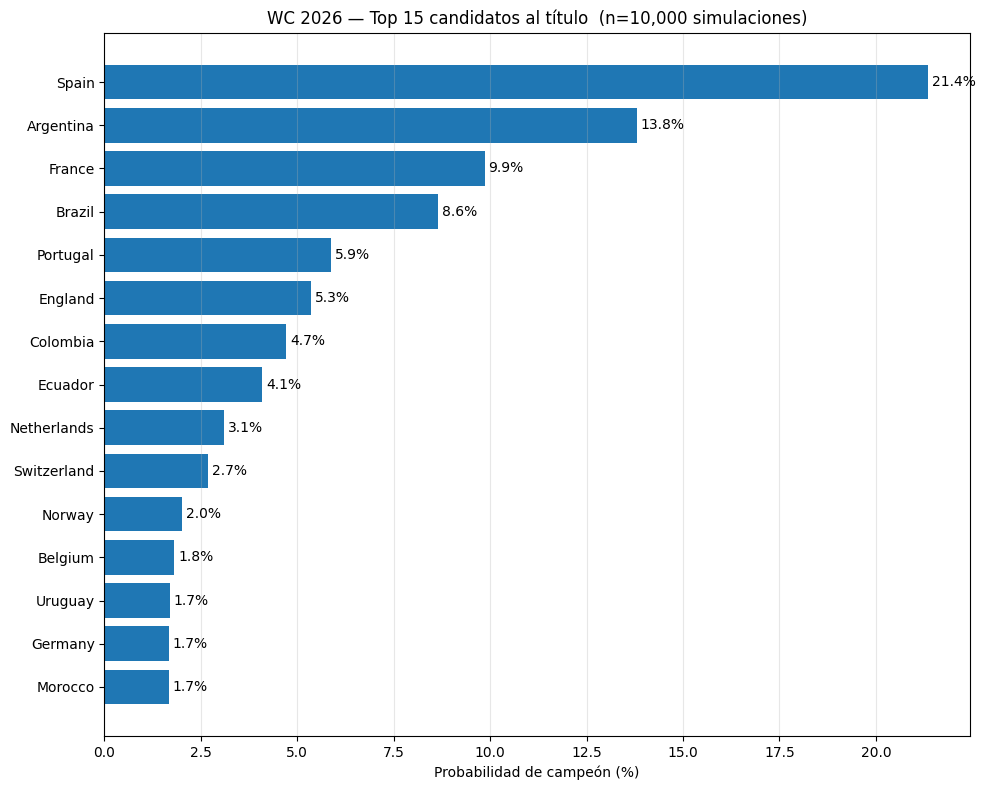

In [16]:
TOP_N = 15
top = df_pred.head(TOP_N).iloc[::-1]   # invertir para barh top-down

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top['Equipo'], top['P_champion'] * 100, color='#1f77b4')
ax.set_xlabel('Probabilidad de campeón (%)')
ax.set_title(f'WC 2026 — Top {TOP_N} candidatos al título  (n={agg.n_iters:,} simulaciones)')
for i, (_, row) in enumerate(top.iterrows()):
    ax.text(row['P_champion'] * 100 + 0.1, i, f'{row["P_champion"]*100:.1f}%', va='center')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'wc2026_champion_probabilities.png', dpi=120, bbox_inches='tight')
plt.show()

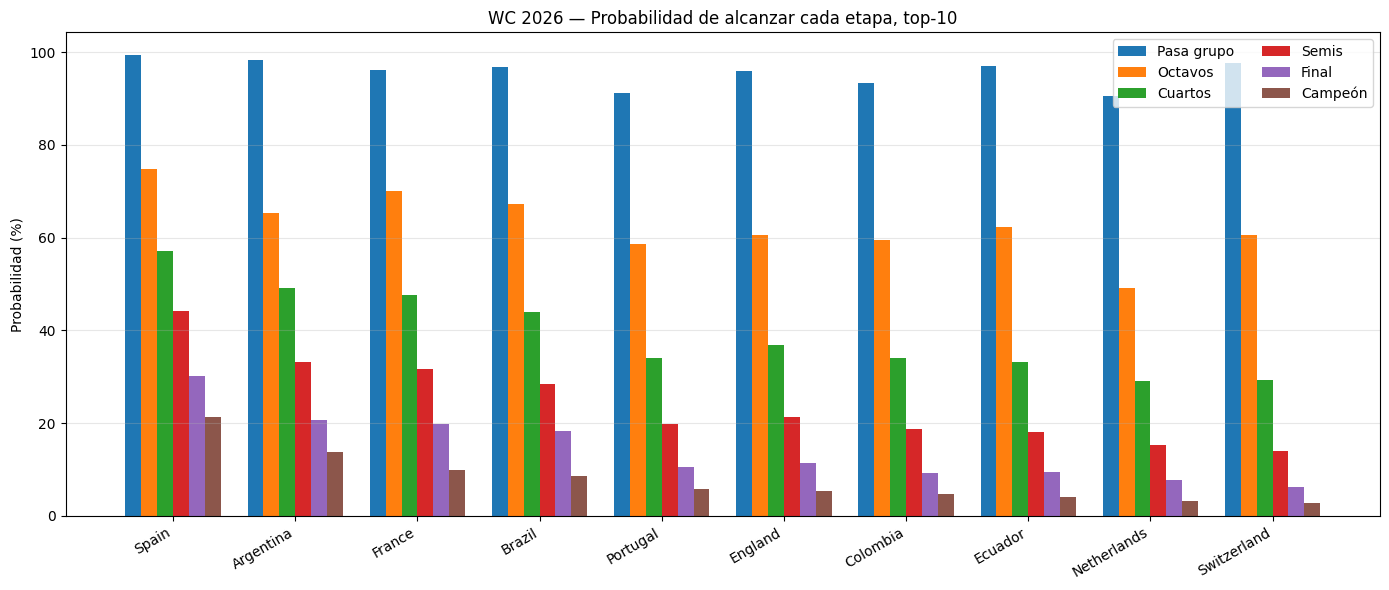

In [17]:
# Barras agrupadas: probabilidad por etapa para los top-10
TOP = 10
top10 = df_pred.head(TOP)

stages = ['P_group_advance', 'P_round_of_16', 'P_quarters', 'P_semis', 'P_final', 'P_champion']
stage_labels = ['Pasa grupo', 'Octavos', 'Cuartos', 'Semis', 'Final', 'Campeón']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(TOP)
width = 0.13
for i, (col, lbl) in enumerate(zip(stages, stage_labels)):
    offset = (i - 2.5) * width
    ax.bar(x + offset, top10[col] * 100, width, label=lbl)
ax.set_xticks(x)
ax.set_xticklabels(top10['Equipo'], rotation=30, ha='right')
ax.set_ylabel('Probabilidad (%)')
ax.set_title(f'WC 2026 — Probabilidad de alcanzar cada etapa, top-{TOP}')
ax.legend(loc='upper right', ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'wc2026_stage_probabilities.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Análisis cualitativo: ¿quién enfrenta a quién más probablemente?

In [18]:
# Para CADA equipo top-10, ver con quién más probable se enfrenta en final
# Esto requiere re-correr 1000 sims y registrar matchups en final
from collections import Counter
import numpy as np

rng = np.random.default_rng(42)
final_matchups = Counter()
champion_finals = defaultdict(Counter)   # champion → Counter de rivals
N_DEEP = 2000

for _ in range(N_DEEP):
    res = simulate_tournament(logreg_predictor, rng)
    if res.champion and res.runner_up:
        pair = tuple(sorted([res.champion, res.runner_up]))
        final_matchups[pair] += 1
        champion_finals[res.champion][res.runner_up] += 1

print('=== Finales más frecuentes (2000 sims) ===')
for pair, count in final_matchups.most_common(10):
    print(f'  {pair[0]:<15} vs {pair[1]:<15}  {count} veces ({100*count/N_DEEP:.1f}%)')

print(f'\n=== Si Argentina llega a la final, ¿contra quién? ===')
if 'Argentina' in champion_finals:
    for rival, count in champion_finals['Argentina'].most_common(5):
        total_arg_finals = sum(champion_finals['Argentina'].values())
        print(f'  vs {rival:<15}  {count} ({100*count/total_arg_finals:.1f}% de las finales con Arg)')
else:
    print('  Argentina no fue campeón en estas 2000 sims')

=== Finales más frecuentes (2000 sims) ===
  France          vs Spain            113 veces (5.7%)
  Argentina       vs Brazil           97 veces (4.8%)
  Brazil          vs Spain            90 veces (4.5%)
  Argentina       vs France           89 veces (4.5%)
  Ecuador         vs Spain            60 veces (3.0%)
  Netherlands     vs Spain            47 veces (2.4%)
  England         vs Spain            42 veces (2.1%)
  France          vs Portugal         38 veces (1.9%)
  Argentina       vs England          33 veces (1.6%)
  Argentina       vs Netherlands      33 veces (1.6%)

=== Si Argentina llega a la final, ¿contra quién? ===
  vs Brazil           62 (22.5% de las finales con Arg)
  vs France           54 (19.6% de las finales con Arg)
  vs Netherlands      20 (7.3% de las finales con Arg)
  vs Ecuador          19 (6.9% de las finales con Arg)
  vs England          17 (6.2% de las finales con Arg)


---
## 8. Diagnóstico: ¿coherente con ELO?

Como sanity check, esperamos que los equipos con mayor ELO inicial sean los favoritos al título.

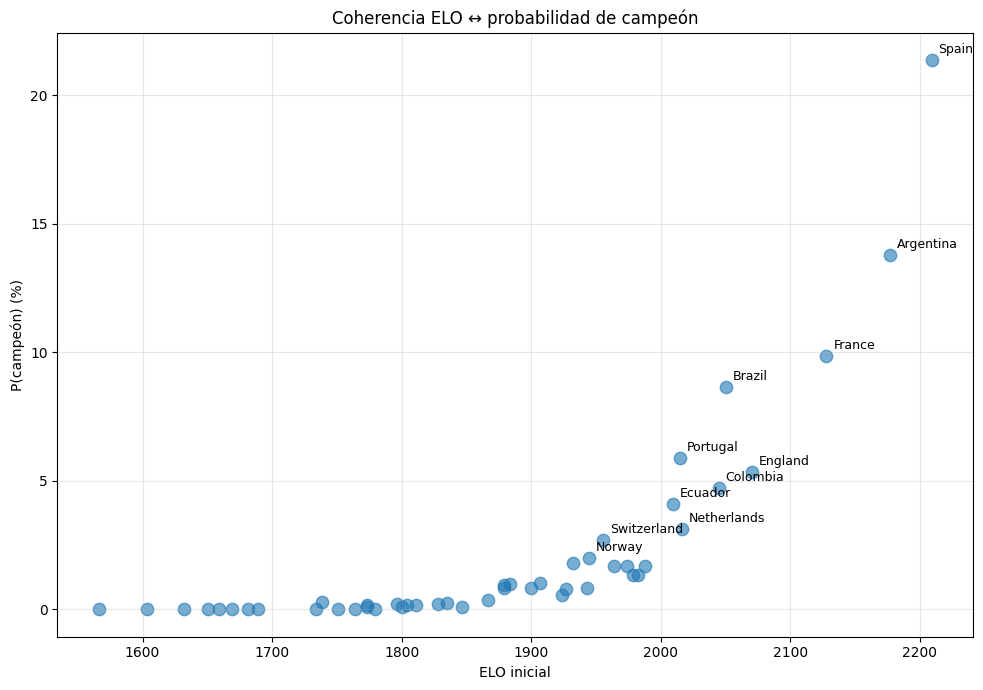


Correlación Spearman ELO ↔ P_champion: ρ = 0.967  (p=7.477e-29)
Esperamos ρ alto (>0.7). Si fuera <0.3 algo está raro.


In [19]:
# Merge con tabla de ELO
df_pred_elo = df_pred.merge(tf_df[['team', 'elo']], left_on='Equipo', right_on='team').drop(columns='team')
df_pred_elo = df_pred_elo.sort_values('P_champion', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df_pred_elo['elo'], df_pred_elo['P_champion'] * 100, alpha=0.6, s=80, c='#1f77b4')
for _, row in df_pred_elo.iterrows():
    if row['P_champion'] > 0.02:
        ax.annotate(row['Equipo'], xy=(row['elo'], row['P_champion'] * 100),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('ELO inicial')
ax.set_ylabel('P(campeón) (%)')
ax.set_title('Coherencia ELO ↔ probabilidad de campeón')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / 'wc2026_elo_vs_champion.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlación de Spearman para chequear monotonicidad
from scipy.stats import spearmanr
rho, p = spearmanr(df_pred_elo['elo'], df_pred_elo['P_champion'])
print(f'\nCorrelación Spearman ELO ↔ P_champion: ρ = {rho:.3f}  (p={p:.3e})')
print('Esperamos ρ alto (>0.7). Si fuera <0.3 algo está raro.')

---
## 9. Suite de tests

In [20]:
import subprocess
result = subprocess.run(
    ['python', '-m', 'pytest', str(ROOT / 'tests' / 'test_simulation.py'), '-v', '--tb=short'],
    capture_output=True, text=True,
)
print(result.stdout[-3500:])
if result.stderr:
    print('STDERR:', result.stderr[-800:])
print(f'Exit code: {result.returncode}')

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.13.0, typeguard-4.5.1, langsmith-0.7.34
collecting ... collected 16 items

drive/MyDrive/d10sformer/tests/test_simulation.py::test_bracket_is_consistent PASSED [  6%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_48_teams_in_groups PASSED [ 12%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_all_teams_have_english_translations PASSED [ 18%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_no_team_appears_twice PASSED [ 25%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_parse_third_slot PASSED [ 31%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_round_of_match PASSED [ 37%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_total_knockout_matches PASSED [ 43%]
drive/MyDrive/d10sformer/tests/test_simulation.py::test_samp

---
## 10. Conclusiones de Fase 6

Llenar al final:

- [ ] Equipos sin datos (fallback default): _____
- [ ] Top 3 candidatos al título:
  1. _____ (___ %)
  2. _____ (___ %)
  3. _____ (___ %)
- [ ] P(Argentina campeón): _____ %
- [ ] Final más probable: _____ vs _____
- [ ] Correlación Spearman ELO ↔ P_champion: _____
- [ ] Tiempo por simulación: _____ ms
- [ ] Tests pasados / total: _____ / 16

**Next:** Fase 7 — pipeline live de actualización durante el Mundial. Cuando los partidos reales se jueguen, fijar resultados y re-simular el bracket restante (las probabilidades cambian dinámicamente).

In [21]:
print('--- Estimación de resultado de partido ---')

# Función auxiliar para obtener el nombre del equipo en inglés
# (Necesario si el usuario ingresa nombres en español y el modelo usa inglés)
def get_team_name(prompt):
    team_name = input(prompt).strip()
    # Try converting to English using SPANISH_TO_ENGLISH, otherwise use as is
    english_name = SPANISH_TO_ENGLISH.get(team_name, team_name)
    # Check if the team is in our known WC_TEAMS list after conversion or directly
    if english_name in WC_TEAMS:
        return english_name
    elif team_name in WC_TEAMS:
        return team_name
    else:
        print(f"Advertencia: '{team_name}' (o '{english_name}') no se encontró en la lista de equipos del Mundial. Usando el nombre ingresado directamente, pero puede haber problemas.")
        return team_name

def predict_score(team_a, team_b, venue='neutral', avg_total_goals=2.5):
    """
    Estima un resultado de partido (goles) basado en las probabilidades de victoria/empate
    del logreg_predictor y una distribución de Poisson con lambdas derivadas.
    Retorna los goles redondeados para una estimación concreta.
    """
    try:
        probs = logreg_predictor(team_a, team_b, venue=venue)
        p_home, p_draw, p_away = probs[0], probs[1], probs[2]
    except KeyError as e:
        print(f"Error interno en predict_score: {e}. Asegúrate de que los nombres de los equipos son correctos.")
        return None, None, None # Return probabilities too for context if needed

    # Derive lambda values for Poisson distributions based on probabilities
    # Distribute total expected goals according to win/draw/loss probabilities
    lambda_a = avg_total_goals * (p_home + (p_draw / 2))
    lambda_b = avg_total_goals * (p_away + (p_draw / 2))

    # Ensure lambdas are reasonable (e.g., non-negative, not excessively small)
    lambda_a = max(0.1, lambda_a)
    lambda_b = max(0.1, lambda_b)

    # To provide a single concrete score, we take the rounded expected goals (mode approximation)
    goals_a = int(round(lambda_a))
    goals_b = int(round(lambda_b))

    return goals_a, goals_b, probs # Return probabilities along with scores

team1_input = get_team_name("Ingresa el nombre del primer equipo (ej. 'Argentina', 'Brasil'): ")
team2_input = get_team_name("Ingresa el nombre del segundo equipo (ej. 'Francia', 'Alemania'): ")

if team1_input and team2_input:
    print(f"\nEstimando resultado para: {team1_input} vs {team2_input}")
    try:
        goals_a, goals_b, probabilities = predict_score(team1_input, team2_input, venue='neutral')
        if goals_a is not None and goals_b is not None:
            print(f"  Estimación de marcador: {team1_input} {goals_a} - {goals_b} {team2_input}")
            print(f"  P(victoria de {team1_input}) = {probabilities[0]:.4f}")
            print(f"  P(empate)             = {probabilities[1]:.4f}")
            print(f"  P(victoria de {team2_input}) = {probabilities[2]:.4f}")
            print(f"  → Suma total: {probabilities.sum():.4f}")
        else:
            print("  No se pudo obtener una estimación de goles debido a un error interno.")
    except Exception as e:
        print(f"Ocurrió un error inesperado al predecir el partido y el marcador: {e}")
else:
    print("No se ingresaron nombres de equipo válidos.")


--- Estimación de resultado de partido ---


KeyboardInterrupt: Interrupted by user

## 11. Simulación completa de un Mundial y visualización del bracket

Vamos a correr una única simulación del Mundial 2026 para ver un posible resultado de principio a fin y luego visualizar el bracket completo.

In [ ]:
print('Corriendo una simulación completa del Mundial 2026...')
# `simulate_tournament` devuelve un objeto TournamentResult
# que contiene los resultados de la simulación.
single_simulation_result = simulate_tournament(logreg_predictor, rng=np.random.default_rng(99))

print(f"\n¡Simulación completa! Campeón: {single_simulation_result.champion}")
print(f"Subcampeón: {single_simulation_result.runner_up}")

### Visualización del Bracket del Mundial

Para visualizar el bracket, necesitamos procesar los resultados de la simulación. La función `simulate_tournament` nos devuelve un objeto `TournamentResult` que contiene los resultados detallados de la fase de grupos y la fase eliminatoria.

**Resultados de la Fase de Grupos (solo equipos clasificados):**



In [ ]:
# Check if single_simulation_result is defined, if not, re-run the simulation
# This relies on `logreg_predictor` and `simulate_tournament` being defined in previous cells.
if 'single_simulation_result' not in globals():
    print('`single_simulation_result` no está definido. Recargando la simulación del Mundial. Esto puede tomar tiempo...')
    single_simulation_result = simulate_tournament(logreg_predictor, rng=np.random.default_rng(99))
    print(f"\n¡Simulación completa recargada! Campeón: {single_simulation_result.champion}")
    print(f"Subcampeón: {single_simulation_result.runner_up}")
else:
    print('Usando `single_simulation_result` ya existente.')

def draw_bracket(ax, sim_result, title="Bracket del Mundial 2026"): # sim_result will be single_simulation_result
    ax.set_facecolor('#F0F0F0') # Light gray background
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')

    # Colors for winners/losers
    WINNER_COLOR = '#4CAF50' # Green
    LOSER_COLOR = '#F44336'  # Red
    DRAW_COLOR = '#FFEB3B'  # Yellow
    TEXT_COLOR = '#333333'
    LINE_COLOR = '#607D8B'
    FONT_SIZE_TEAM = 10
    FONT_SIZE_SCORE = 9

    # --- Group Stage (Left side - Now presented textually or separately) ---
    # This part of the code is commented out/removed to simplify the visual bracket
    # The group stage results are now described in a markdown cell above.

    # --- Knockout Stage (Main bracket visualization) ---
    # Define positions for rounds (adjust x-coordinates as needed)
    x_round32 = 15 # Changed from 50
    x_round16 = 40 # New round added for 48 teams
    x_quarters = 60 # Changed from 65
    x_semis = 75 # Changed from 80
    x_final = 90 # Changed from 95

    # Round of 32 (Octavos de Final for 48 teams)
    ax.text(x_round32, 100, "Ronda de 32", fontsize=14, fontweight='bold', color=TEXT_COLOR, ha='center')
    y_round_start_r32 = 95 # Adjusted start position
    match_spacing_r32 = 5.5 # Increased spacing for 16 matches

    r32_matches = [m for m in sim_result.knockout_results if m.round == 'Round of 32']
    for i, match in enumerate(r32_matches):
        y_pos_center = y_round_start_r32 - i * match_spacing_r32
        y_pos_home = y_pos_center + 0.7
        y_pos_away = y_pos_center - 0.7

        winner_team = match.winner

        ax.text(x_round32 - 2, y_pos_home, match.home_team, fontsize=FONT_SIZE_TEAM, ha='right',
                color=WINNER_COLOR if match.home_team == winner_team else LOSER_COLOR)
        ax.text(x_round32 - 2, y_pos_away, match.away_team, fontsize=FONT_SIZE_TEAM, ha='right',
                color=WINNER_COLOR if match.away_team == winner_team else LOSER_COLOR)
        ax.text(x_round32, y_pos_center, f"({match.home_score}-{match.away_score})", fontsize=FONT_SIZE_SCORE, ha='center', color=TEXT_COLOR)

        # Line connecting to next round
        ax.plot([x_round32 + 3, x_round32 + 5], [y_pos_center, y_pos_center], color=LINE_COLOR, lw=1)


    # Round of 16 (Octavos de Final)
    ax.text(x_round16, 100, "Octavos de Final", fontsize=14, fontweight='bold', color=TEXT_COLOR, ha='center')
    y_round_start_r16 = y_round_start_r32 - (match_spacing_r32/2) # Start between R32 matches
    match_spacing_r16 = match_spacing_r32 * 2 # Adjusted spacing

    r16_matches = [m for m in sim_result.knockout_results if m.round == 'Round of 16']
    for i, match in enumerate(r16_matches):
        y_pos_center = y_round_start_r16 - i * match_spacing_r16
        y_pos_home = y_pos_center + 0.7
        y_pos_away = y_pos_center - 0.7

        winner_team = match.winner

        ax.text(x_round16 - 2, y_pos_home, match.home_team, fontsize=FONT_SIZE_TEAM, ha='right',
                color=WINNER_COLOR if match.home_team == winner_team else LOSER_COLOR)
        ax.text(x_round16 - 2, y_pos_away, match.away_team, fontsize=FONT_SIZE_TEAM, ha='right',
                color=WINNER_COLOR if match.away_team == winner_team else LOSER_COLOR)
        ax.text(x_round16, y_pos_center, f"({match.home_score}-{match.away_score})", fontsize=FONT_SIZE_SCORE, ha='center', color=TEXT_COLOR)

        # Line connecting to next round
        ax.plot([x_round16 + 3, x_round16 + 5], [y_pos_center, y_pos_center], color=LINE_COLOR, lw=1)

    # Quarter-finals (Cuartos de Final)
    ax.text(x_quarters, 100, "Cuartos de Final", fontsize=14, fontweight='bold', color=TEXT_COLOR, ha='center')
    y_quarter_start = y_round_start_r16 - (match_spacing_r16/2) # Start between R16 matches
    match_spacing_qf = match_spacing_r16 * 2 # Adjusted spacing

    qf_matches = [m for m in sim_result.knockout_results if m.round == 'Quarter-finals']
    for i, match in enumerate(qf_matches):
        y_pos_center = y_quarter_start - i * match_spacing_qf
        y_pos_home = y_pos_center + 0.7
        y_pos_away = y_pos_center - 0.7

        winner_team = match.winner

        ax.text(x_quarters - 2, y_pos_home, match.home_team, fontsize=FONT_SIZE_TEAM, ha='right',
                color=WINNER_COLOR if match.home_team == winner_team else LOSER_COLOR)
        ax.text(x_quarters - 2, y_pos_away, match.away_team, fontsize=FONT_SIZE_TEAM, ha='right',
                color=WINNER_COLOR if match.away_team == winner_team else LOSER_COLOR)
        ax.text(x_quarters, y_pos_center, f"({match.home_score}-{match.away_score})", fontsize=FONT_SIZE_SCORE, ha='center', color=TEXT_COLOR)

        # Line connecting to next round
        ax.plot([x_quarters + 3, x_quarters + 5], [y_pos_center, y_pos_center], color=LINE_COLOR, lw=1)

    # Semi-finals (Semifinales)
    ax.text(x_semis, 100, "Semifinales", fontsize=14, fontweight='bold', color=TEXT_COLOR, ha='center')
    y_semi_start = y_quarter_start - (match_spacing_qf/2) # Start between QF matches
    match_spacing_sf = match_spacing_qf * 2

    sf_matches = [m for m in sim_result.knockout_results if m.round == 'Semi-finals']
    for i, match in enumerate(sf_matches):
        y_pos_center = y_semi_start - i * match_spacing_sf
        y_pos_home = y_pos_center + 0.7
        y_pos_away = y_pos_center - 0.7

        winner_team = match.winner

        ax.text(x_semis - 2, y_pos_home, match.home_team, fontsize=FONT_SIZE_TEAM, ha='right',
                color=WINNER_COLOR if match.home_team == winner_team else LOSER_COLOR)
        ax.text(x_semis - 2, y_pos_away, match.away_team, fontsize=FONT_SIZE_TEAM, ha='right',
                color=WINNER_COLOR if match.away_team == winner_team else LOSER_COLOR)
        ax.text(x_semis, y_pos_center, f"({match.home_score}-{match.away_score})", fontsize=FONT_SIZE_SCORE, ha='center', color=TEXT_COLOR)

        # Line connecting to final
        ax.plot([x_semis + 3, x_semis + 5], [y_pos_center, y_pos_center], color=LINE_COLOR, lw=1)

    # Final (Final)
    ax.text(x_final, 100, "Final", fontsize=14, fontweight='bold', color=TEXT_COLOR, ha='center')
    final_match = next((m for m in sim_result.knockout_results if m.round == 'Final'), None)
    if final_match:
        y_pos_center_f = y_semi_start - (match_spacing_sf/2)
        y_pos_home_f = y_pos_center_f + 0.7
        y_pos_away_f = y_pos_center_f - 0.7

        winner_team_f = final_match.winner

        ax.text(x_final - 2, y_pos_home_f, final_match.home_team, fontsize=FONT_SIZE_TEAM + 1, ha='right',
                color=WINNER_COLOR if final_match.home_team == winner_team_f else LOSER_COLOR, fontweight='bold')
        ax.text(x_final - 2, y_pos_away_f, final_match.away_team, fontsize=FONT_SIZE_TEAM + 1, ha='right',
                color=WINNER_COLOR if final_match.away_team == winner_team_f else LOSER_COLOR, fontweight='bold')
        ax.text(x_final, y_pos_center_f, f"({final_match.home_score}-{final_match.away_score})", fontsize=FONT_SIZE_SCORE + 1, ha='center', color=TEXT_COLOR, fontweight='bold')

        # Champion Text
        ax.text(x_final, y_pos_center_f - 5, f"Campeón: {sim_result.champion}", fontsize=18, fontweight='extra-bold', color=WINNER_COLOR, ha='center')


    # Legend
    winner_patch = mpatches.Patch(color=WINNER_COLOR, label='Ganador')
    loser_patch = mpatches.Patch(color=LOSER_COLOR, label='Perdedor')
    ax.legend(handles=[winner_patch, loser_patch], loc='lower right', bbox_to_anchor=(1.0, 0.05), fontsize=10)

    ax.set_xlim(-5, 105)
    ax.set_ylim(-10, 105)


# Create the plot
fig, ax = plt.subplots(figsize=(25, 20)) # Increased figure size
draw_bracket(ax, single_simulation_result)
plt.tight_layout()
plt.savefig(REPORTS / 'wc2026_single_simulation_bracket.png', dpi=150, bbox_inches='tight')
plt.show()


# Display Group Stage results in a more readable format
print("\n--- Clasificación de la Fase de Grupos ---")
for group_name in sorted(single_simulation_result.group_stage_results.keys()):
    group_data = single_simulation_result.group_stage_results[group_name]
    print(f"\n**{group_name.replace('_', ' ')}**")
    # Sort teams by points, then goal difference, then goals scored
    sorted_teams = sorted(group_data.teams.values(), key=lambda t: (t.points, t.goal_difference, t.goals_scored), reverse=True)
    for i, team_res in enumerate(sorted_teams):
        status = "(Clasificado)" if i < 2 or team_res.third_place_qualifier else ""
        print(f"  {team_res.team:<20} Pts: {team_res.points} GD: {team_res.goal_difference} {status}")
